# Eq.(8) in Wu+22 prediction tests for selection bias

This notebook section loads the saved HDF5 outputs for:

- $Y_{\rm cyl}$-selected profiles.
- $N_{\rm cyl}$richness-selected profiles.

It then makes the validation plots:

\begin{equation}
B_{\rm sim,mm}(r_p)=
\frac{\langle T(r_p)\rangle_{\rm selected}}
{\langle T(r_p)\rangle_{\rm mass\ matched}},
\qquad
B_{\rm Eq8,mm}(r_p)=
\frac{\langle T(r_p)\rangle_{\rm Eq8\ pred}}
{\langle T(r_p)\rangle_{\rm mass\ matched}}.
\end{equation}

The main comparison is `bias_sim_mm` versus the derived quantity `eq8_pred / exp_mm_mean`.

The notebook also plots:
- selected versus mass-matched mass PDFs,
- Eq.8 model ingredients $r(M,r_p)$, $\sigma_T(M,r_p)$, and $\sigma_S(M)$,
- selection diagnostics $\eta_S=\langle[\ln S-\mu_S(M)]/\sigma_S(M)\rangle_{\rm sel}$ when selected proxy/mass arrays are present in the file.


In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
# from pathlib import Path

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"



YCYL_FILE = "data/wu22_eq8_Ycyl_selected_profiles_proj300_nscy_linear_with_mm_mPDF.h5"
RICH_FILE = "data/wu22_eq8_gdens1.0e-02_q180_proj300_chi6_mz20_with_mm_mPDF.h5"


# Ycyl selector and survey.
YCYL_SELECTOR = "Y500c_true"
YCYL_SURVEY_IDX = 2  # 0: ACT_DR6, 1: ACT_DR6_Legacy, 2: SPT_SZ, 3: SPTpol_500d

# Richness bin index.
# 0: lambda >= 60, 1: 45 <= lambda < 60, 2: 30 <= lambda < 45, 3: 20 <= lambda < 30
RICH_BIN_IDX = 0


SURVEY_LABELS = ["ACT-DR6", "ACT-DR6 Legacy", "SPT-SZ", "SPTpol 500d"]
RICHNESS_BIN_LABELS = [
    r"$\lambda\in[60,\infty)$",
    r"$\lambda\in[45,60)$",
    r"$\lambda\in[30,45)$",
    r"$\lambda\in[20,30)$",
]

print("Ycyl file:", YCYL_FILE)
print("Richness file:", RICH_FILE)
# print("Output figure directory:", OUTDIR.resolve())


Ycyl file: data/wu22_eq8_Ycyl_selected_profiles_proj300_nscy_linear_with_mm_mPDF.h5
Richness file: data/wu22_eq8_gdens1.0e-02_q180_proj300_chi6_mz20_with_mm_mPDF.h5


In [2]:
# ---------------------------------------------------------------------
# Generic HDF5 helpers
# ---------------------------------------------------------------------

def safe_divide(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.full(np.broadcast_shapes(num.shape, den.shape), np.nan, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        val = num / den
    good = np.isfinite(num) & np.isfinite(den) & (den != 0.0)
    out[good] = val[good]
    return out


def finite_positive(x):
    x = np.asarray(x, dtype=float)
    return np.isfinite(x) & (x > 0)


def get_dataset_if_present(group, key, default=None):
    return group[key][:] if key in group else default


def take_indexed(arr, idx):
    """Return arr[idx] for arrays with a leading selection dimension; return arr unchanged if 1D."""
    arr = np.asarray(arr)
    if arr.ndim == 0:
        return arr[()]
    if arr.ndim == 1:
        return arr
    return arr[idx]


def _decode_strings(arr):
    arr = np.asarray(arr)
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return out


def print_h5_tree(fname, max_depth=3):
    """Quick HDF5 tree printer for debugging dataset paths."""
    # fname = Path(fname)
    with h5py.File(fname, "r") as f:
        def visitor(name, obj):
            depth = name.count("/")
            if depth > max_depth:
                return
            indent = "  " * depth
            if isinstance(obj, h5py.Dataset):
                print(f"{indent}{name}  shape={obj.shape}")
            else:
                print(f"{indent}{name}/")
        f.visititems(visitor)


def result_paths(source, selector, obs):
    """
    Return result/model/meta paths for one case.

    source = "ycyl" or "richness".
    """
    if source == "ycyl":
        if selector is None:
            raise ValueError("Ycyl source requires selector, e.g. selector='Y500c_true'.")
        result_path = f"selection_sets/{selector}/results/{obs}"
        model_path  = f"selection_sets/{selector}/kllr_models/{obs}"
        meta_path   = f"selection_sets/{selector}/meta"
    elif source == "richness":
        result_path = f"results/{obs}"
        model_path  = f"kllr_models/{obs}"
        meta_path   = f"results/{obs}"
    else:
        raise ValueError("source must be 'ycyl' or 'richness'.")
    return result_path, model_path, meta_path


def list_observables(fname, source, selector=None):
    # fname = Path(fname)
    with h5py.File(fname, "r") as f:
        if source == "ycyl":
            return list(f[f"selection_sets/{selector}/results"].keys())
        return list(f["results"].keys())


def load_result_case(fname, source, obs, idx, selector=None, label=None):
    """
    Load one selected-sample / observable combination.

    Returned dictionary includes:
    - measured mass-matched bias: bias_sim_mm
    - Eq.8 predicted mass-matched bias: bias_eq8_mm = eq8_pred / exp_mm_mean
    - Eq.8 pure residual model ratio: bias_eq8_model = eq8_pred / eq8_base
    """
    # fname = Path(fname)
    result_path, model_path, meta_path = result_paths(source, selector, obs)

    with h5py.File(fname, "r") as f:
        if result_path not in f:
            raise KeyError(f"Missing result path: {result_path}")
        g = f[result_path]

        # rp can be in the result group, radial_grids, or top-level.
        if "rp" in g:
            rp = g["rp"][:]
        elif source == "richness" and f"radial_grids/{obs}" in f:
            rp = f[f"radial_grids/{obs}"][:]
        elif "rp" in f:
            rp = f["rp"][:]
        else:
            raise KeyError(f"Could not find rp for {result_path}")

        obs_mean = take_indexed(g["obs_mean"][:], idx)
        obs_err = take_indexed(g["obs_err"][:], idx) if "obs_err" in g else np.full_like(obs_mean, np.nan)

        exp_mean = take_indexed(g["exp_mean"][:], idx)
        exp_err = take_indexed(g["exp_err"][:], idx) if "exp_err" in g else np.full_like(exp_mean, np.nan)

        exp_mm_mean = take_indexed(g["exp_mm_mean"][:], idx) if "exp_mm_mean" in g else np.full_like(exp_mean, np.nan)
        exp_mm_err = take_indexed(g["exp_mm_err"][:], idx) if "exp_mm_err" in g else np.full_like(exp_mean, np.nan)
        exp_mm_std = take_indexed(g["exp_mm_std"][:], idx) if "exp_mm_std" in g else np.full_like(exp_mean, np.nan)

        eq8_base = take_indexed(g["eq8_base"][:], idx)
        eq8_pred = take_indexed(g["eq8_pred"][:], idx)

        # Saved ratios if available.
        bias_sim = take_indexed(g["bias_sim"][:], idx) if "bias_sim" in g else safe_divide(obs_mean, exp_mean)
        bias_sim_mm = take_indexed(g["bias_sim_mm"][:], idx) if "bias_sim_mm" in g else safe_divide(obs_mean, exp_mm_mean)
        bias_eq8 = take_indexed(g["bias_eq8"][:], idx) if "bias_eq8" in g else safe_divide(eq8_pred, exp_mean)
        bias_eq8_model = take_indexed(g["bias_eq8_model"][:], idx) if "bias_eq8_model" in g else safe_divide(eq8_pred, eq8_base)

        bias_sim_err = take_indexed(g["bias_sim_err"][:], idx) if "bias_sim_err" in g else np.full_like(obs_mean, np.nan)
        bias_sim_mm_err = take_indexed(g["bias_sim_mm_err"][:], idx) if "bias_sim_mm_err" in g else np.full_like(obs_mean, np.nan)
        bias_sim_mm_scatter = take_indexed(g["bias_sim_mm_scatter"][:], idx) if "bias_sim_mm_scatter" in g else np.full_like(obs_mean, np.nan)

        if "bias_sim_mm_realizations" in g:
            bias_sim_mm_realizations = g["bias_sim_mm_realizations"][idx, :, :]
        elif "exp_mm_all" in g:
            exp_mm_all = g["exp_mm_all"][idx, :, :]
            bias_sim_mm_realizations = safe_divide(obs_mean[None, :], exp_mm_all)
        else:
            bias_sim_mm_realizations = None

        # The main Task-5 derived quantity:
        bias_eq8_mm = safe_divide(eq8_pred, exp_mm_mean)
        bias_eq8_mm_err = np.full_like(bias_eq8_mm, np.nan)
        good = finite_positive(exp_mm_mean) & np.isfinite(exp_mm_err) & np.isfinite(bias_eq8_mm)
        bias_eq8_mm_err[good] = np.abs(bias_eq8_mm[good]) * np.abs(exp_mm_err[good] / exp_mm_mean[good])

        # Mass PDF diagnostics.
        if meta_path in f:
            gm = f[meta_path]
            M_centers = take_indexed(gm["M_centers"][:], idx) if "M_centers" in gm else None
            if source == "ycyl":
                pdf_sel = take_indexed(gm["pdf_mass"][:], idx) if "pdf_mass" in gm else None
            else:
                pdf_sel = take_indexed(gm["pdf_rich"][:], idx) if "pdf_rich" in gm else None
            pdf_mm = take_indexed(gm["pdf_massmatched"][:], idx) if "pdf_massmatched" in gm else None
            counts_sel = take_indexed(gm["counts_sel_mass"][:], idx) if "counts_sel_mass" in gm else None
            counts_mm = take_indexed(gm["counts_massmatched"][:], idx) if "counts_massmatched" in gm else None
            counts_parent = take_indexed(gm["counts_parent_mass"][:], idx) if "counts_parent_mass" in gm else None
        else:
            M_centers = pdf_sel = pdf_mm = counts_sel = counts_mm = counts_parent = None

        attrs = dict(f.attrs.items())

    return dict(
        fname=fname,
        source=source,
        selector=selector,
        obs=obs,
        idx=int(idx),
        label=label or f"{source}:{selector or ''}:{obs}:{idx}",
        rp=np.asarray(rp, dtype=float),
        obs_mean=obs_mean,
        obs_err=obs_err,
        exp_mean=exp_mean,
        exp_err=exp_err,
        exp_mm_mean=exp_mm_mean,
        exp_mm_err=exp_mm_err,
        exp_mm_std=exp_mm_std,
        eq8_base=eq8_base,
        eq8_pred=eq8_pred,
        bias_sim=bias_sim,
        bias_sim_err=bias_sim_err,
        bias_sim_mm=bias_sim_mm,
        bias_sim_mm_err=bias_sim_mm_err,
        bias_sim_mm_scatter=bias_sim_mm_scatter,
        bias_sim_mm_realizations=bias_sim_mm_realizations,
        bias_eq8=bias_eq8,
        bias_eq8_mm=bias_eq8_mm,
        bias_eq8_mm_err=bias_eq8_mm_err,
        bias_eq8_model=bias_eq8_model,
        M_centers=M_centers,
        pdf_sel=pdf_sel,
        pdf_mm=pdf_mm,
        counts_sel=counts_sel,
        counts_mm=counts_mm,
        counts_parent=counts_parent,
        attrs=attrs,
    )


In [3]:
# ---------------------------------------------------------------------
# Define the cases to test.
# ---------------------------------------------------------------------

case_specs = [
    dict(
        fname=YCYL_FILE,
        source="ycyl",
        selector=YCYL_SELECTOR,
        obs="Sigma",
        idx=YCYL_SURVEY_IDX,
        label=fr"$Y_{{\rm cyl}}$ selected, {SURVEY_LABELS[YCYL_SURVEY_IDX]}, $\Sigma$",
    ),
    dict(
        fname=YCYL_FILE,
        source="ycyl",
        selector=YCYL_SELECTOR,
        obs="cy_true",
        idx=YCYL_SURVEY_IDX,
        label=fr"$Y_{{\rm cyl}}$ selected, {SURVEY_LABELS[YCYL_SURVEY_IDX]}, $y$",
    ),
    dict(
        fname=RICH_FILE,
        source="richness",
        selector=None,
        obs="Sigma",
        idx=RICH_BIN_IDX,
        label=fr"$N_{{\rm cyl}}$ selected, {RICHNESS_BIN_LABELS[RICH_BIN_IDX]}, $\Sigma$",
    ),
    dict(
        fname=RICH_FILE,
        source="richness",
        selector=None,
        obs="cy",
        idx=RICH_BIN_IDX,
        label=fr"$N_{{\rm cyl}}$ selected, {RICHNESS_BIN_LABELS[RICH_BIN_IDX]}, $y$",
    ),
]

# Load all cases once.
cases = [load_result_case(**spec) for spec in case_specs]

for c in cases:
    print(c["label"])
    print("  rp shape:", c["rp"].shape)
    print("  obs_mean shape:", c["obs_mean"].shape)
    print("  finite bias_sim_mm:", np.sum(np.isfinite(c["bias_sim_mm"])), "/", c["bias_sim_mm"].size)
    print("  finite bias_eq8_mm:", np.sum(np.isfinite(c["bias_eq8_mm"])), "/", c["bias_eq8_mm"].size)


$Y_{\rm cyl}$ selected, SPT-SZ, $\Sigma$
  rp shape: (20,)
  obs_mean shape: (20,)
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$Y_{\rm cyl}$ selected, SPT-SZ, $y$
  rp shape: (20,)
  obs_mean shape: (20,)
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$N_{\rm cyl}$ selected, $\lambda\in[60,\infty)$, $\Sigma$
  rp shape: (20,)
  obs_mean shape: (20,)
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$N_{\rm cyl}$ selected, $\lambda\in[60,\infty)$, $y$
  rp shape: (20,)
  obs_mean shape: (20,)
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20


# Figures
### Include: (i) $Y_{\rm cyl}$-selected samples for both SPT-SZ and SPTpol-500d, and (ii) $N_{\rm cyl}$-selected samples for all four richness bins, each for both $\Sigma$ and $y$.


In [4]:

# ---------------------------------------------------------------------
# Extra subplot helpers for additional surveys / richness bins.
# ---------------------------------------------------------------------

def _fill_band(ax, x, y, yerr, *, color, alpha=0.18, label=None, zorder=1):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)
    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)
    if np.any(good):
        ax.fill_between(
            x[good],
            y[good] - yerr[good],
            y[good] + yerr[good],
            color=color,
            alpha=alpha,
            label=label,
            zorder=zorder,
        )

def build_ycyl_cases_for_surveys(survey_indices=(2, 3), selector=YCYL_SELECTOR):
    """
    Build cases for Ycyl-selected samples for the requested survey indices.

    Default: SPT-SZ (2) and SPTpol-500d (3).
    Returns cases in the order:
        [survey0 Sigma, survey0 cy_true, survey1 Sigma, survey1 cy_true, ...]
    so a 2-column plot naturally places Sigma on the left and y on the right.
    """
    specs = []
    for survey_idx in survey_indices:
        specs.extend([
            dict(
                fname=YCYL_FILE,
                source="ycyl",
                selector=selector,
                obs="Sigma",
                idx=survey_idx,
                label=fr"$Y_{{\rm cyl}}$ selected, {SURVEY_LABELS[survey_idx]}, $\Sigma$",
            ),
            dict(
                fname=YCYL_FILE,
                source="ycyl",
                selector=selector,
                obs="cy_true",
                idx=survey_idx,
                label=fr"$Y_{{\rm cyl}}$ selected, {SURVEY_LABELS[survey_idx]}, $y$",
            ),
        ])
    return [load_result_case(**spec) for spec in specs]


def build_richness_cases_for_bins(bin_indices=(0, 1, 2, 3)):
    """
    Build cases for Ncyl-selected samples for the requested richness bins.

    Returns cases in the order:
        [bin0 Sigma, bin0 cy, bin1 Sigma, bin1 cy, ...]
    so a 2-column plot naturally places Sigma on the left and y on the right.
    """
    specs = []
    for bin_idx in bin_indices:
        specs.extend([
            dict(
                fname=RICH_FILE,
                source="richness",
                selector=None,
                obs="Sigma",
                idx=bin_idx,
                label=fr"$N_{{\rm cyl}}$ selected, {RICHNESS_BIN_LABELS[bin_idx]}, $\Sigma$",
            ),
            dict(
                fname=RICH_FILE,
                source="richness",
                selector=None,
                obs="cy",
                idx=bin_idx,
                label=fr"$N_{{\rm cyl}}$ selected, {RICHNESS_BIN_LABELS[bin_idx]}, $y$",
            ),
        ])
    return [load_result_case(**spec) for spec in specs]


def plot_bias_cases_grid(cases, ncols=2, figsize_per_panel=(5.8, 3.2), savepath=None,
                         ylim=None, legend=True, legend_loc="upper center",
                         legend_ncol=1, title_fs=18, xlabel_fs=18, ylabel_fs=16):
    """
    Generic multi-panel plot for measured/predicted obs./exp. ratios using the
    same four curves as the clean notebook figure:
        - measured B_sim,mm
        - measured B_sim,mPDF
        - predicted B_Eq8,mm
        - predicted B_Eq8,mPDF
    plus the propagated error band on measured B_sim,mm.
    """
    ncases = len(cases)
    nrows = int(np.ceil(ncases / ncols))
    fig_w = figsize_per_panel[0] * ncols
    fig_h = figsize_per_panel[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharex=False)
    axes = np.atleast_1d(axes).ravel()

    c_meas_mm = "C0"
    c_meas_mpdf = "C3"
    c_eq8_mm = "C1"
    c_eq8_mpdf = "C2"

    for ax, c in zip(axes, cases):
        rp = c["rp"]
        ax.axhline(1.0, linestyle=":", linewidth=1.2, color="0.4", zorder=0)

        # Measured mass-matched ratio and its propagated uncertainty.
        ax.plot(
            rp, c["bias_sim_mm"], marker="o", linewidth=1.8, color=c_meas_mm,
            label=r"measured $B_{\rm sim,mm}$", zorder=4,
        )
        if np.any(np.isfinite(c["bias_sim_mm_err"])):
            _fill_band(
                ax, rp, c["bias_sim_mm"], c["bias_sim_mm_err"],
                color=c_meas_mm, alpha=0.15, label=None, zorder=1,
            )

        # Measured mPDF-weighted ratio.
        ax.plot(
            rp, c["bias_sim"], marker="s", ls="--", ms=3, linewidth=1.2,
            color=c_meas_mpdf, label=r"measured $B_{\rm sim,mPDF}$", zorder=4,
        )

        # Eq.8 with the same mass-matched denominator.
        ax.plot(
            rp, c["bias_eq8_mm"], marker="s", linewidth=1.8, color=c_eq8_mm,
            label=r"predicted $B_{\rm Eq8,mm}$", zorder=5,
        )

        # Eq.8 with the mPDF denominator.
        ax.plot(
            rp, c["bias_eq8"], marker="d", ls=":", ms=3, linewidth=1.8,
            color=c_eq8_mpdf, label=r"predicted $B_{\rm Eq8,mPDF}$", zorder=5,
        )

        ax.set_xscale("log")
        ax.set_title(c["label"], fontsize=title_fs)
        ax.set_xlabel(r"$r_p\,[h^{-1}{\rm cMpc}]$", fontsize=xlabel_fs)
        ax.set_ylabel("Ratio: obs./expec.", fontsize=ylabel_fs)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.grid(True, which="both", alpha=0.25)

    # Hide any unused axes.
    for ax in axes[ncases:]:
        ax.set_visible(False)

    if legend and ncases > 0:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc=legend_loc, ncol=legend_ncol, frameon=False, fontsize=13)
        top_rect = 0.93 if legend_loc == "upper center" else 1.0
        fig.tight_layout(rect=[0, 0, 1, top_rect])
    else:
        fig.tight_layout()

    if savepath is not None:
        savepath = Path(savepath)
        fig.savefig(savepath, dpi=180, bbox_inches="tight")
        fig.savefig(savepath.with_suffix(".pdf"), bbox_inches="tight")
        print("Saved:", savepath)
        print("Saved:", savepath.with_suffix(".pdf"))

    return fig, axes



$Y_{\rm cyl}$ selected, SPT-SZ, $\Sigma$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$Y_{\rm cyl}$ selected, SPT-SZ, $y$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$Y_{\rm cyl}$ selected, SPTpol 500d, $\Sigma$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$Y_{\rm cyl}$ selected, SPTpol 500d, $y$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20


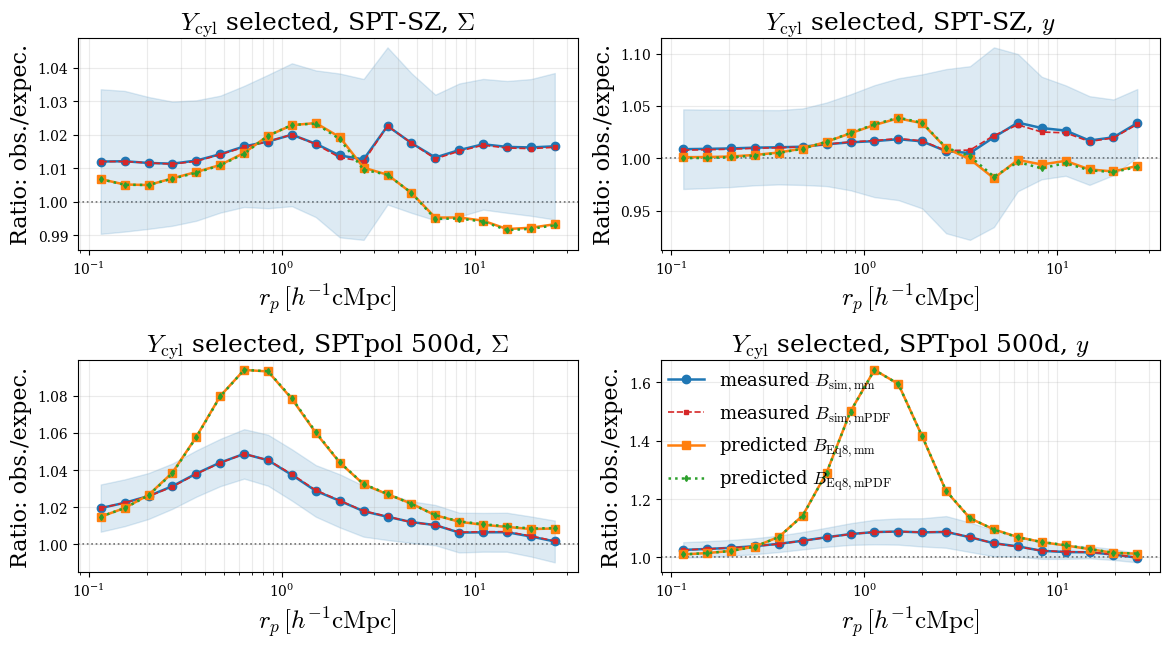

In [5]:

# ---------------------------------------------------------------------
# Additional Figure 1: Ycyl-selected samples for SPT-SZ and SPTpol-500d.
# ---------------------------------------------------------------------

ycyl_cases_extra = build_ycyl_cases_for_surveys(survey_indices=(2, 3), selector=YCYL_SELECTOR)

for c in ycyl_cases_extra:
    print(c["label"])
    print("  finite bias_sim_mm:", np.sum(np.isfinite(c["bias_sim_mm"])), "/", c["bias_sim_mm"].size)
    print("  finite bias_eq8_mm:", np.sum(np.isfinite(c["bias_eq8_mm"])), "/", c["bias_eq8_mm"].size)

fig, axes = plot_bias_cases_grid(
    ycyl_cases_extra,
    ncols=2,
    figsize_per_panel=(5.9, 3.3),
    savepath=None,# "measured_vs_eq8_bias_ycyl_SPTSZ_SPTpol.pdf",
    ylim=None,
    legend=True,
    legend_loc=[0.565,0.23],##"upper center",
    legend_ncol=1,
)
plt.show()



$N_{\rm cyl}$ selected, $\lambda\in[60,\infty)$, $\Sigma$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$N_{\rm cyl}$ selected, $\lambda\in[60,\infty)$, $y$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$N_{\rm cyl}$ selected, $\lambda\in[45,60)$, $\Sigma$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$N_{\rm cyl}$ selected, $\lambda\in[45,60)$, $y$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$N_{\rm cyl}$ selected, $\lambda\in[30,45)$, $\Sigma$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$N_{\rm cyl}$ selected, $\lambda\in[30,45)$, $y$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$N_{\rm cyl}$ selected, $\lambda\in[20,30)$, $\Sigma$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20
$N_{\rm cyl}$ selected, $\lambda\in[20,30)$, $y$
  finite bias_sim_mm: 20 / 20
  finite bias_eq8_mm: 20 / 20


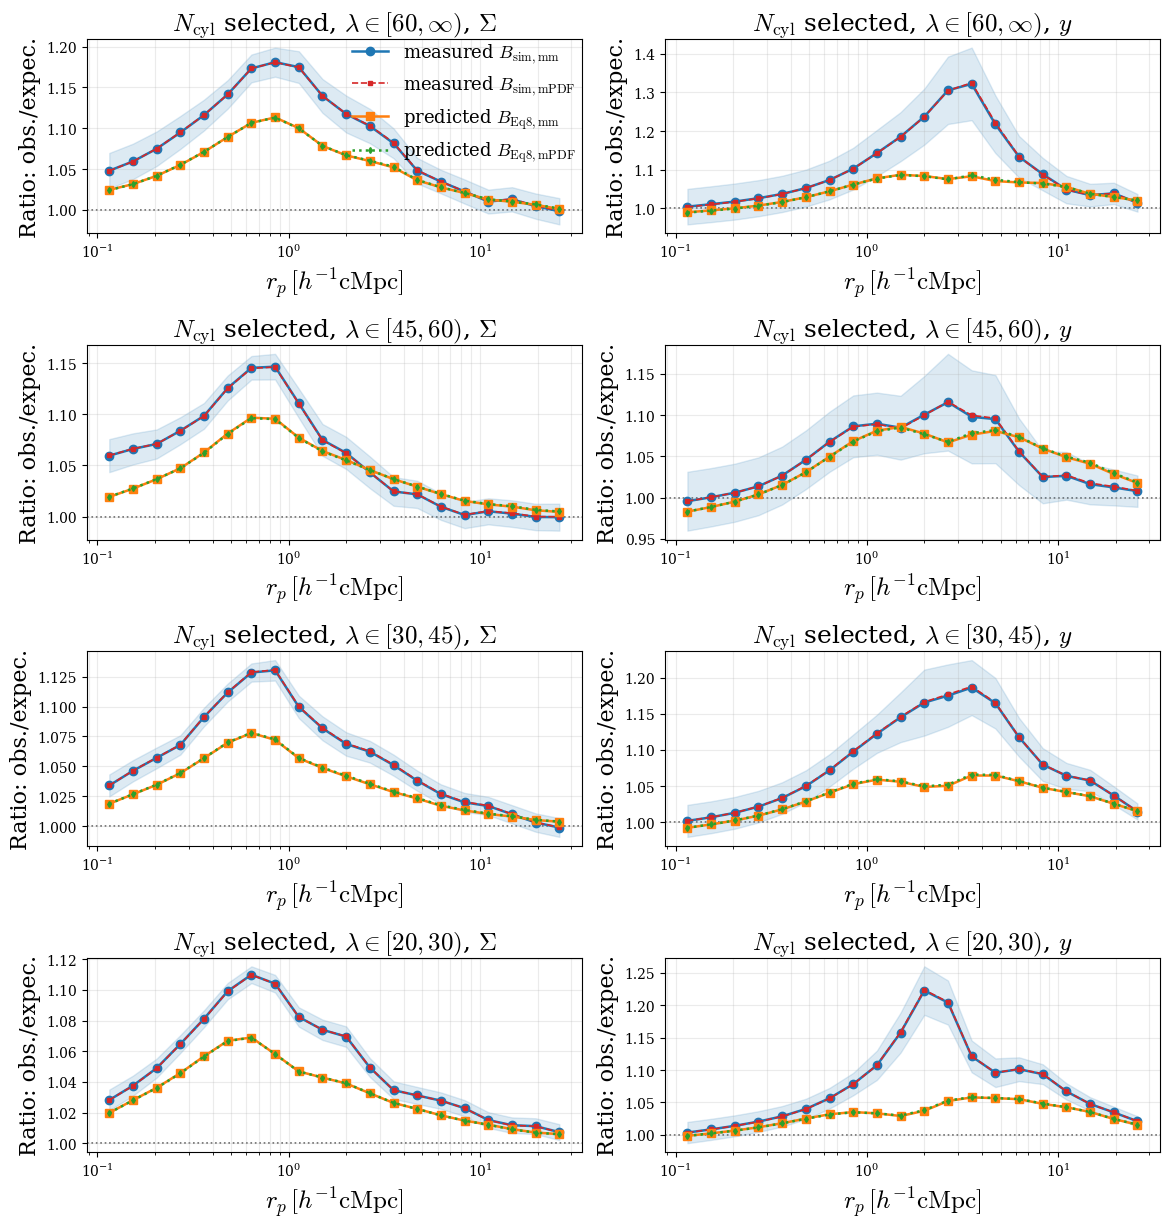

In [6]:

# ---------------------------------------------------------------------
# Additional Figure 2: Ncyl-selected samples for all four richness bins.
# ---------------------------------------------------------------------

rich_cases_allbins = build_richness_cases_for_bins(bin_indices=(0, 1, 2, 3))

for c in rich_cases_allbins:
    print(c["label"])
    print("  finite bias_sim_mm:", np.sum(np.isfinite(c["bias_sim_mm"])), "/", c["bias_sim_mm"].size)
    print("  finite bias_eq8_mm:", np.sum(np.isfinite(c["bias_eq8_mm"])), "/", c["bias_eq8_mm"].size)

fig, axes = plot_bias_cases_grid(
    rich_cases_allbins,
    ncols=2,
    figsize_per_panel=(5.9, 3.1),
    savepath=None, #"measured_vs_eq8_bias_richness_allbins.pdg",
    ylim=None,
    legend=True,
    legend_loc=[0.295,0.86],#"upper center",
    legend_ncol=1,
)
plt.show()



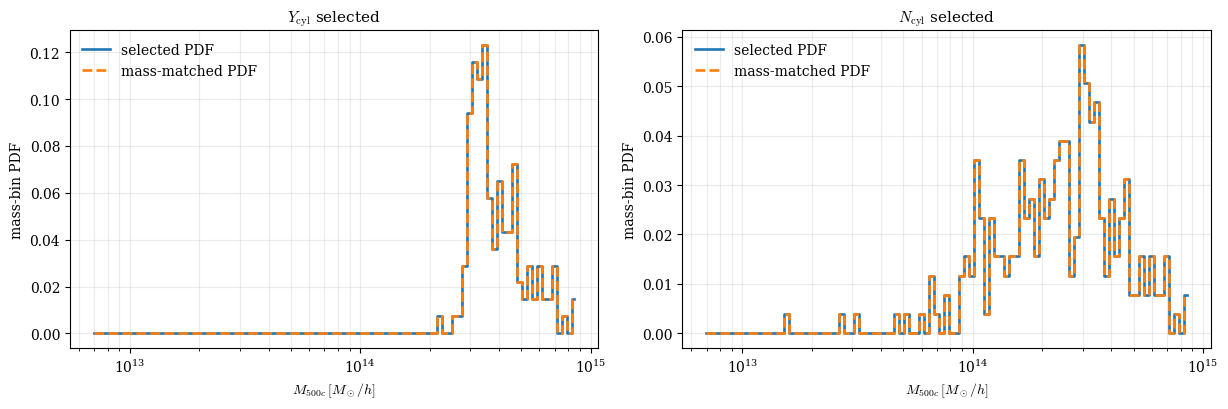

In [7]:
# ---------------------------------------------------------------------
# Test: selected-sample mass PDF versus mass-matched mass PDF.
# This confirms that the denominator is genuinely mass-matched.
# ---------------------------------------------------------------------

def plot_mass_pdf_comparison(cases_for_pdf, savepath=None):
    n = len(cases_for_pdf)
    fig, axes = plt.subplots(1, n, figsize=(6.2 * n, 4.2), squeeze=False)
    axes = axes.ravel()

    for ax, c in zip(axes, cases_for_pdf):
        M = c["M_centers"]
        psel = c["pdf_sel"]
        pmm = c["pdf_mm"]

        if M is None or psel is None or pmm is None:
            ax.text(0.5, 0.5, "mass PDF not found", transform=ax.transAxes, ha="center", va="center")
            ax.set_title(c["label"])
            continue

        M = np.asarray(M, dtype=float)
        psel = np.asarray(psel, dtype=float)
        pmm = np.asarray(pmm, dtype=float)
        good = finite_positive(M) & np.isfinite(psel) & np.isfinite(pmm)

        ax.step(M[good], psel[good], where="mid", linewidth=1.9, label="selected PDF")
        ax.step(M[good], pmm[good], where="mid", linewidth=1.9, linestyle="--", label="mass-matched PDF")

        ax.set_xscale("log")
        ax.set_xlabel(r"$M_{500c}\,[M_\odot/h]$")
        ax.set_ylabel("mass-bin PDF")
        ax.set_title(c["label"].split(",")[0], fontsize=11)
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(frameon=False)

    fig.tight_layout()
    if savepath is not None:
        savepath = Path(savepath)
        fig.savefig(savepath, dpi=180, bbox_inches="tight")
        fig.savefig(savepath.with_suffix(".pdf"), bbox_inches="tight")
        print("Saved:", savepath)
        print("Saved:", savepath.with_suffix(".pdf"))
    return fig, axes


# Mass PDFs do not depend on the target observable, so use one Sigma case for each selector.
# Case0: Ycyl-selected (SPT-SZ) \Sigma
# Case1: Ycyl-selected (SPT-SZ) cy
# Case2: Ncyl-selected \lambda \in [60, \infty) \Sigma
# Case3: Ncyl-selected \lambda \in [60, \infty) cy
fig, axes = plot_mass_pdf_comparison(
    [cases[0], cases[2]],
    savepath=None, #"selected_vs_massmatched_vs_masspdf.pdf",
)
plt.show()


## Positive-only correlation heatmaps

This section replaces/overrides the previous heatmap plotting helper so that correlation-coefficient panels show only positive correlations, \(r>0\). Non-positive and non-finite correlation coefficients are masked and plotted as blank/white. The scatter panels are unchanged and keep a common colorbar range for comparison.



In [8]:

# ---------------------------------------------------------------------
# Positive-only correlation heatmap helpers
# ---------------------------------------------------------------------
# These cells are self-contained apart from the existing notebook helpers:
#   result_paths(...), load_result_case(...), YCYL_FILE, RICH_FILE,
#   YCYL_SELECTOR, SURVEY_LABELS, RICHNESS_BIN_LABELS, OUTDIR.
# ---------------------------------------------------------------------

from matplotlib.colors import Normalize
from pathlib import Path


def load_eq8_model(fname, source, obs, selector=None):
    """
    Load the saved Eq.8/KLLR model group for one proxy-target pair.
    The returned r and sig_Y arrays are parent-sample quantities.
    """
    fname = Path(fname)
    _, model_path, _ = result_paths(source, selector, obs)

    with h5py.File(fname, "r") as f:
        if model_path not in f:
            raise KeyError(f"Missing model path: {model_path}")
        g = f[model_path]
        model = dict(
            xg_X=g["xg_X"][:],
            mu_X=g["mu_X"][:],
            sig_X=g["sig_X"][:],
            xg_Y=g["xg_Y"][:],
            mu_Y=g["mu_Y"][:],
            sig_Y=g["sig_Y"][:],
            r=g["r"][:],
            y_mode=g.attrs.get("y_mode", ""),
            model_path=model_path,
        )
    return model


def centres_to_edges(x, log=True):
    """Convert 1D bin centres to bin edges."""
    x = np.asarray(x, dtype=float).squeeze()
    if x.ndim != 1:
        raise ValueError(f"x must be 1D after squeeze; got shape {x.shape}")
    if x.size < 2:
        raise ValueError("Need at least two centres to compute edges.")
    if not np.all(np.isfinite(x)):
        raise ValueError("Non-finite centres found.")

    if log:
        if np.any(x <= 0):
            raise ValueError("All centres must be positive for log-space edges.")
        lx = np.log(x)
        le = np.empty(x.size + 1, dtype=float)
        le[1:-1] = 0.5 * (lx[:-1] + lx[1:])
        le[0] = lx[0] - (le[1] - lx[0])
        le[-1] = lx[-1] + (lx[-1] - le[-2])
        return np.exp(le)

    e = np.empty(x.size + 1, dtype=float)
    e[1:-1] = 0.5 * (x[:-1] + x[1:])
    e[0] = x[0] - (e[1] - x[0])
    e[-1] = x[-1] + (x[-1] - e[-2])
    return e


def weighted_quantile_from_pdf(x, pdf, qs=(0.16, 0.50, 0.84)):
    """Weighted quantiles from mass-bin centres and a PDF."""
    x = np.asarray(x, dtype=float)
    pdf = np.asarray(pdf, dtype=float)
    good = np.isfinite(x) & (x > 0) & np.isfinite(pdf) & (pdf > 0)
    if np.sum(good) < 2:
        return np.full(len(qs), np.nan)

    x = x[good]
    w = pdf[good]
    order = np.argsort(x)
    x = x[order]
    w = w[order]
    w = w / np.sum(w)
    cdf = np.cumsum(w)
    return np.interp(qs, cdf, x)


def get_mass_pdf_quantiles(case, qs=(0.16, 0.50, 0.84)):
    return weighted_quantile_from_pdf(case.get("M_centers", None), case.get("pdf_sel", None), qs=qs)


def proxy_target_tex(case):
    """Return LaTeX strings for selection proxy and target profile."""
    if case["source"] == "ycyl":
        proxy_tex = r"Y_{\rm cyl}"
    elif case["source"] == "richness":
        proxy_tex = r"N_{\rm cyl}"
    else:
        proxy_tex = r"s_2"

    obs = str(case["obs"])
    if obs in ("Sigma", "sig", "Sig"):
        target_tex = r"\Sigma"
    elif obs in ("cy", "cy_true", "cy_so_baseline_noise", "ns_cy"):
        target_tex = r"y"
    elif obs in ("DS", "DeltaSigma"):
        target_tex = r"\Delta\Sigma"
    elif "Sigma_g" in obs or "sigg" in obs:
        target_tex = r"\Sigma_g"
    else:
        target_tex = obs.replace("_", r"\_")

    return proxy_tex, target_tex


def case_short_label(case):
    if case["source"] == "ycyl":
        return SURVEY_LABELS[int(case["idx"])]
    if case["source"] == "richness":
        return RICHNESS_BIN_LABELS[int(case["idx"])]
    return f"idx={case['idx']}"


def prepare_heatmap_arrays(case):
    """
    Load parent r(M,rp) and sigma_1(M,rp) arrays for one proxy-target pair.

    Returns
    -------
    M : 1D mass grid, Msun/h
    rp : 1D radius grid, cMpc/h
    R : 2D residual correlation matrix, shape (n_rp, n_M)
    S : 2D target scatter matrix, shape (n_rp, n_M)
    model : loaded model dictionary
    """
    model = load_eq8_model(case["fname"], case["source"], case["obs"], selector=case["selector"])

    M = np.exp(np.asarray(model["xg_Y"], dtype=float)).squeeze()
    rp = np.asarray(case["rp"], dtype=float).squeeze()
    R_raw = np.asarray(model["r"], dtype=float)
    S_raw = np.asarray(model["sig_Y"], dtype=float)

    # Saved model arrays should be (mass, rp). If already transposed, handle it.
    if R_raw.shape == (M.size, rp.size):
        R = R_raw.T
    elif R_raw.shape == (rp.size, M.size):
        R = R_raw
    else:
        raise ValueError(f"Cannot align model['r'] shape {R_raw.shape} with M={M.size}, rp={rp.size}")

    if S_raw.shape == (M.size, rp.size):
        S = S_raw.T
    elif S_raw.shape == (rp.size, M.size):
        S = S_raw
    else:
        raise ValueError(f"Cannot align model['sig_Y'] shape {S_raw.shape} with M={M.size}, rp={rp.size}")

    good_M = np.isfinite(M) & (M > 0)
    good_rp = np.isfinite(rp) & (rp > 0)

    M = M[good_M]
    rp = rp[good_rp]
    R = R[np.ix_(good_rp, good_M)]
    S = S[np.ix_(good_rp, good_M)]

    return M, rp, R, S, model


def compute_common_scatter_range(cases, scatter_vmin=0.0, scatter_vmax=None, percentile=None):
    """Compute common sigma_1 colorbar range across heatmap cases."""
    if scatter_vmax is not None:
        return float(scatter_vmin), float(scatter_vmax)

    vals = []
    for case in cases:
        _, _, _, S, _ = prepare_heatmap_arrays(case)
        good = np.isfinite(S) & (S >= 0)
        if np.any(good):
            vals.append(S[good])

    if len(vals) == 0:
        return float(scatter_vmin), 1.0

    vals = np.concatenate(vals)
    vmax = np.nanmax(vals) if percentile is None else np.nanpercentile(vals, percentile)
    if not np.isfinite(vmax) or vmax <= scatter_vmin:
        vmax = 1.0
    return float(scatter_vmin), float(vmax)


def make_positive_only_matrix(R, positive_threshold=0.0):
    """
    Mask correlation coefficients <= positive_threshold.
    This leaves only positive correlations visible.
    """
    R = np.asarray(R, dtype=float)
    mask = (~np.isfinite(R)) | (R <= positive_threshold)
    R_pos = np.ma.masked_where(mask, R)
    positive_vals = R[(~mask) & np.isfinite(R)]
    return R_pos, positive_vals


def add_multiple_mass_pdf_overlays(
    ax,
    cases,
    labels=None,
    colors=None,
    alpha=0.12,
    median_lw=1.8,
    edge_lw=1.2,
    band_zorder=4,
    edge_zorder=5,
    median_zorder=6,
):
    """
    Overlay multiple selected-sample mass ranges.
      shaded band = 16--84% selected mass range
      dotted edges = q16 and q84
      dashed line = median selected mass
    """
    if labels is None:
        labels = [case_short_label(c) for c in cases]
    if colors is None:
        colors = [f"C{i}" for i in range(len(cases))]

    handles = []
    for case, label, color in zip(cases, labels, colors):
        q16, q50, q84 = get_mass_pdf_quantiles(case)
        if np.isfinite(q16) and np.isfinite(q84) and q16 < q84:
            ax.axvspan(q16, q84, facecolor=color, alpha=alpha, edgecolor="none", zorder=band_zorder)
            ax.axvline(q16, color=color, linestyle=":", linewidth=edge_lw, alpha=0.95, zorder=edge_zorder)
            ax.axvline(q84, color=color, linestyle=":", linewidth=edge_lw, alpha=0.95, zorder=edge_zorder)
        if np.isfinite(q50):
            h = ax.axvline(q50, color=color, linestyle="--", linewidth=median_lw,
                           alpha=0.95, zorder=median_zorder, label=label)
            handles.append(h)
    return handles


def plot_eq8_heatmaps_multi_overlay_positive_corr(
    base_case,
    overlay_cases,
    *,
    savepath=None,
    positive_threshold=0.0,
    corr_vmin=0.0,
    corr_vmax=1.0,
    corr_cmap="viridis",
    masked_color="white",
    scatter_cmap="viridis",
    scatter_vmin=0.0,
    scatter_vmax=None,
    overlay_labels=None,
    overlay_colors=None,
    overlay_alpha=0.12,
    print_positive_fraction=True,
):
    """
    Two-panel parent heatmap:
      left  = positive-only parent residual correlation r_12(M,rp), showing only r>0
      right = parent target scatter sigma_1(M,rp)
    Multiple selected-sample mass ranges can be overlaid on both panels.
    """
    M, rp, R, S, model = prepare_heatmap_arrays(base_case)
    R_pos, positive_vals = make_positive_only_matrix(R, positive_threshold=positive_threshold)

    if positive_vals.size == 0:
        print(f"[warn] No r > {positive_threshold} pixels for {base_case['label']}")
    elif print_positive_fraction:
        print(
            f"{base_case['label']}: positive pixels = {positive_vals.size}/{R.size} "
            f"({100*positive_vals.size/R.size:.1f}%), "
            f"positive r range = [{np.nanmin(positive_vals):.3f}, {np.nanmax(positive_vals):.3f}]"
        )

    x_edges = centres_to_edges(M, log=True)
    y_edges = centres_to_edges(rp, log=True)
    proxy_tex, target_tex = proxy_target_tex(base_case)

    cmap_corr = plt.get_cmap(corr_cmap).copy()
    cmap_corr.set_bad(color=masked_color, alpha=1.0)
    corr_norm = Normalize(vmin=corr_vmin, vmax=corr_vmax)

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), sharex=True, sharey=True)

    mesh0 = axes[0].pcolormesh(
        x_edges,
        y_edges,
        R_pos,
        shading="auto",
        cmap=cmap_corr,
        norm=corr_norm,
    )

    mesh1 = axes[1].pcolormesh(
        x_edges,
        y_edges,
        S,
        shading="auto",
        cmap=scatter_cmap,
        vmin=scatter_vmin,
        vmax=scatter_vmax,
    )

    axes[0].set_facecolor(masked_color)
    axes[0].set_title(
        fr"$r_{{\delta\ln {proxy_tex},\,\delta\ln {target_tex}}}"
        fr"(\ln M_{{500c}}, r_p)>0$",
        fontsize=16,
    )
    axes[1].set_title(
        fr"$\sigma_{{\delta\ln {target_tex}}}(\ln M_{{500c}}, r_p)$",
        fontsize=16,
    )

    handles0 = None
    for ax in axes:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"$M_{500c}\,[h^{-1}M_\odot]$", fontsize=18)
        ax.tick_params(axis="both", which="both", labelsize=15, length=6, width=0.8,
                       top=True, right=True, direction="in")
        ax.tick_params(axis="both", which="major", length=9, width=1.0,
                       top=True, right=True, direction="in")
        ax.minorticks_on()
        ax.grid(False)

        handles = add_multiple_mass_pdf_overlays(
            ax,
            overlay_cases,
            labels=overlay_labels,
            colors=overlay_colors,
            alpha=overlay_alpha,
        )
        if handles0 is None:
            handles0 = handles

    axes[0].set_ylabel(r"$r_p\,[h^{-1}{\rm cMpc}]$", fontsize=18)

    cbar0 = fig.colorbar(mesh0, ax=axes[0], pad=0.02)
    cbar0.set_label(
        fr"${{\rm Corr}}[\delta\ln {proxy_tex},\,\delta\ln {target_tex}]>0$",
        fontsize=16,
    )
    cbar0.ax.tick_params(labelsize=14)

    cbar1 = fig.colorbar(mesh1, ax=axes[1], pad=0.02)
    cbar1.set_label(fr"$\sigma_{{\delta\ln {target_tex}}}$", fontsize=16)
    cbar1.ax.tick_params(labelsize=14)

    if handles0:
        fig.legend(
            handles=handles0,
            loc="upper center",
            ncol=min(len(handles0), 4),
            frameon=False,
            fontsize=13,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        fig.tight_layout()

    if savepath is not None:
        savepath = Path(savepath)
        fig.savefig(savepath, dpi=180, bbox_inches="tight")
        fig.savefig(savepath.with_suffix(".pdf"), bbox_inches="tight")
        print("Saved:", savepath)
        print("Saved:", savepath.with_suffix(".pdf"))

    return fig, axes



Common sigma_1 colorbar range: [0, 1.023]
$Y_{\rm cyl}$ selected, SPT-SZ, Sigma: positive pixels = 394/400 (98.5%), positive r range = [0.027, 0.856]


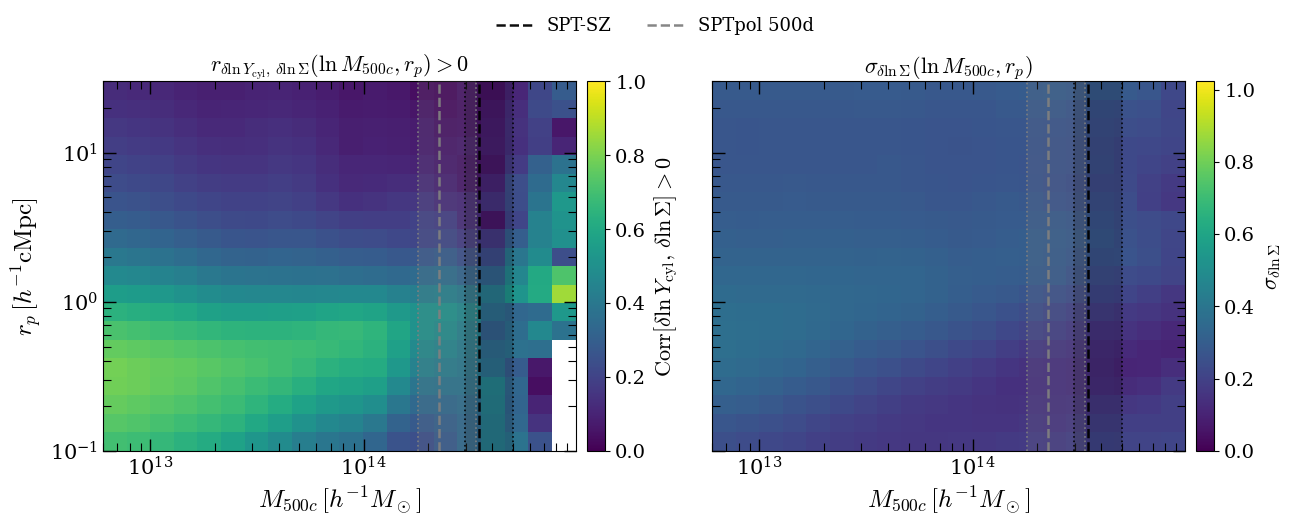

$Y_{\rm cyl}$ selected, SPT-SZ, cy_true: positive pixels = 400/400 (100.0%), positive r range = [0.009, 0.999]


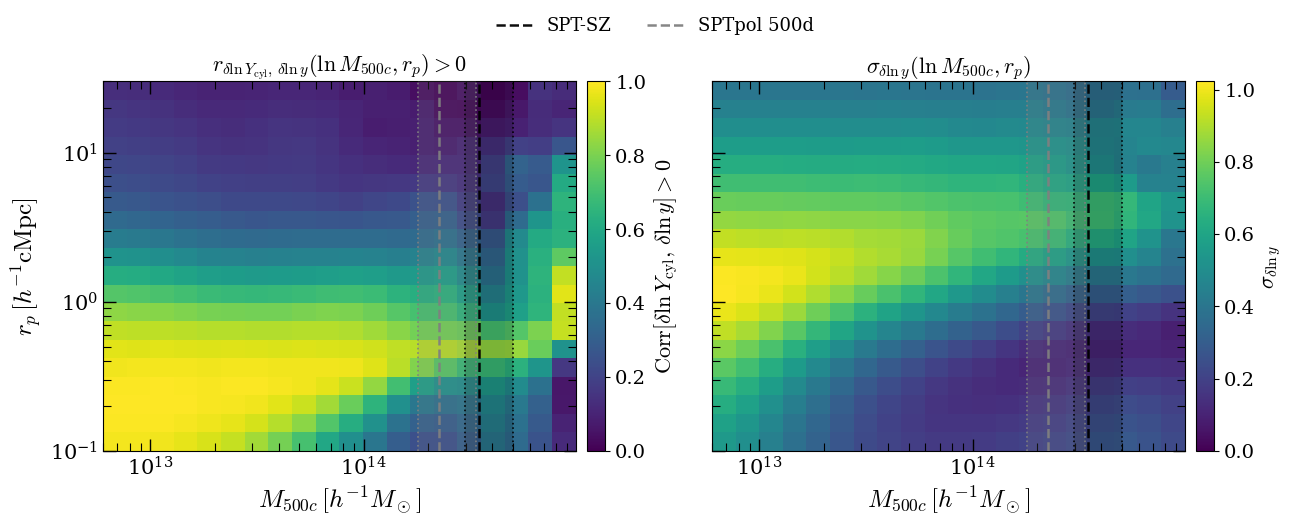

$N_{\rm cyl}$ selected, $\lambda\in[60,\infty)$, Sigma: positive pixels = 395/400 (98.8%), positive r range = [0.002, 0.831]


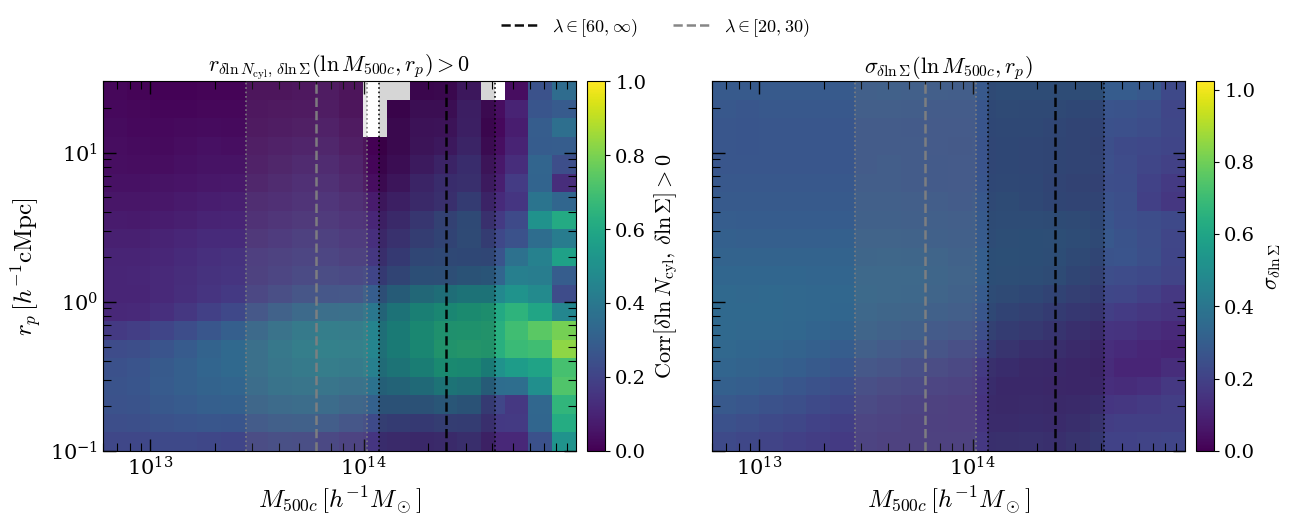

$N_{\rm cyl}$ selected, $\lambda\in[60,\infty)$, cy: positive pixels = 367/400 (91.8%), positive r range = [0.002, 0.408]


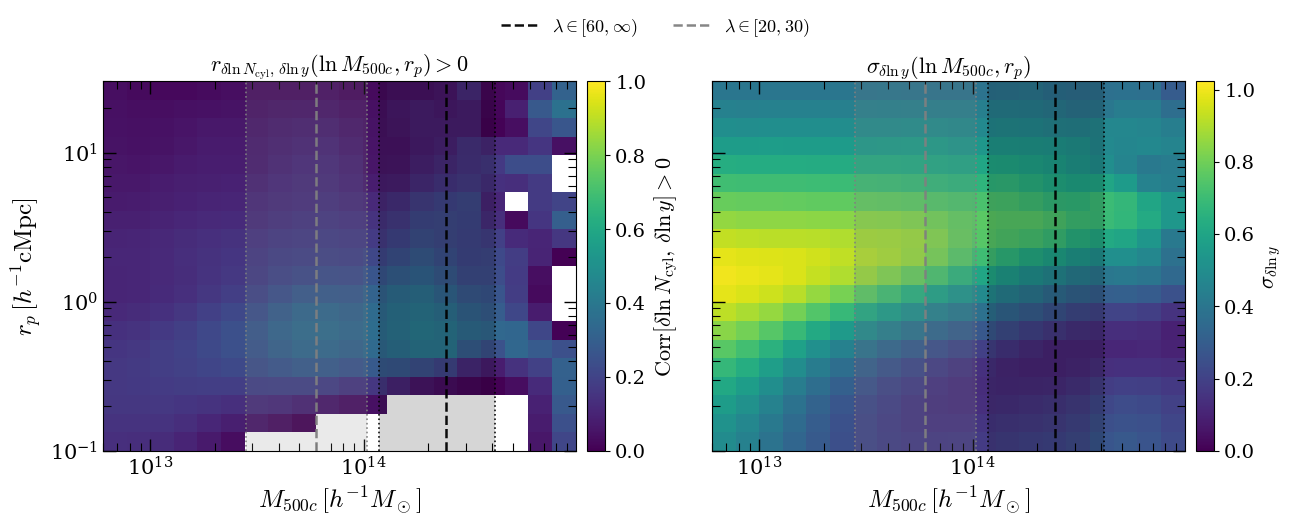

In [9]:

# ---------------------------------------------------------------------
# Build the four proxy-target pairs and save positive-only-correlation heatmaps.
# ---------------------------------------------------------------------
# This makes four figures:
#   1) Ycyl -- Sigma
#   2) Ycyl -- y
#   3) Ncyl -- Sigma
#   4) Ncyl -- y
# In each figure, the correlation panel only shows r>0; r<=0 is blank/white.
# ---------------------------------------------------------------------

# Survey overlays for Ycyl top-N samples.
YCYL_HEATMAP_SURVEY_INDICES = [2, 3]  # SPT-SZ and SPTpol-500d

# Richness overlays. Use [0, 3] to avoid clutter, or [0, 1, 2, 3] for all bins.
RICH_OVERLAY_BIN_INDICES = [0, 3]


def _make_case(source, obs, idx, selector=None):
    if source == "ycyl":
        label = fr"$Y_{{\rm cyl}}$ selected, {SURVEY_LABELS[idx]}, {obs}"
        return load_result_case(
            fname=YCYL_FILE,
            source="ycyl",
            selector=selector or YCYL_SELECTOR,
            obs=obs,
            idx=idx,
            label=label,
        )
    elif source == "richness":
        label = fr"$N_{{\rm cyl}}$ selected, {RICHNESS_BIN_LABELS[idx]}, {obs}"
        return load_result_case(
            fname=RICH_FILE,
            source="richness",
            selector=None,
            obs=obs,
            idx=idx,
            label=label,
        )
    else:
        raise ValueError("source must be 'ycyl' or 'richness'")


# Ycyl pair cases: each list contains the same parent heatmap but different selected mass overlays.
ycyl_sigma_cases = [_make_case("ycyl", "Sigma", i, selector=YCYL_SELECTOR) for i in YCYL_HEATMAP_SURVEY_INDICES]
ycyl_cy_cases    = [_make_case("ycyl", "cy_true", i, selector=YCYL_SELECTOR) for i in YCYL_HEATMAP_SURVEY_INDICES]

# Ncyl pair cases: same parent heatmap but different richness-bin mass overlays.
rich_sigma_cases = [_make_case("richness", "Sigma", i) for i in RICH_OVERLAY_BIN_INDICES]
rich_cy_cases    = [_make_case("richness", "cy", i) for i in RICH_OVERLAY_BIN_INDICES]

# Common scatter colorbar range across the four parent scatter panels.
heatmap_base_cases = [
    ycyl_sigma_cases[0],
    ycyl_cy_cases[0],
    rich_sigma_cases[0],
    rich_cy_cases[0],
]

COMMON_SCATTER_VMIN = 0.0
COMMON_SCATTER_VMAX = None       # set manually if desired, e.g. 1.0
COMMON_SCATTER_PERCENTILE = None # set e.g. 99.5 to reduce outlier influence

scatter_vmin, scatter_vmax = compute_common_scatter_range(
    heatmap_base_cases,
    scatter_vmin=COMMON_SCATTER_VMIN,
    scatter_vmax=COMMON_SCATTER_VMAX,
    percentile=COMMON_SCATTER_PERCENTILE,
)
print(f"Common sigma_1 colorbar range: [{scatter_vmin:.4g}, {scatter_vmax:.4g}]")



# Overlay styles.
ycyl_overlay_labels = [SURVEY_LABELS[i] for i in YCYL_HEATMAP_SURVEY_INDICES]
ycyl_overlay_colors = ["black", "gray"]
rich_overlay_labels = [RICHNESS_BIN_LABELS[i] for i in RICH_OVERLAY_BIN_INDICES]
rich_overlay_colors = ["black", "gray", "C2", "C3"][:len(RICH_OVERLAY_BIN_INDICES)]

# 1) Ycyl -- Sigma
fig, axes = plot_eq8_heatmaps_multi_overlay_positive_corr(
    base_case=ycyl_sigma_cases[0],
    overlay_cases=ycyl_sigma_cases,
    overlay_labels=ycyl_overlay_labels,
    overlay_colors=ycyl_overlay_colors,
    overlay_alpha=0.16,
    positive_threshold=0.0,
    corr_vmin=0.0,
    corr_vmax=1.0,
    corr_cmap="viridis",
    scatter_cmap="viridis",
    scatter_vmin=scatter_vmin,
    scatter_vmax=scatter_vmax,
    savepath=None,
)
plt.show()

# 2) Ycyl -- y
fig, axes = plot_eq8_heatmaps_multi_overlay_positive_corr(
    base_case=ycyl_cy_cases[0],
    overlay_cases=ycyl_cy_cases,
    overlay_labels=ycyl_overlay_labels,
    overlay_colors=ycyl_overlay_colors,
    overlay_alpha=0.16,
    positive_threshold=0.0,
    corr_vmin=0.0,
    corr_vmax=1.0,
    corr_cmap="viridis",
    scatter_cmap="viridis",
    scatter_vmin=scatter_vmin,
    scatter_vmax=scatter_vmax,
    savepath=None, 
)
plt.show()

# 3) Ncyl -- Sigma
fig, axes = plot_eq8_heatmaps_multi_overlay_positive_corr(
    base_case=rich_sigma_cases[0],
    overlay_cases=rich_sigma_cases,
    overlay_labels=rich_overlay_labels,
    overlay_colors=rich_overlay_colors,
    overlay_alpha=0.16,
    positive_threshold=0.0,
    corr_vmin=0.0,
    corr_vmax=1.0,
    corr_cmap="viridis",
    scatter_cmap="viridis",
    scatter_vmin=scatter_vmin,
    scatter_vmax=scatter_vmax,
    savepath=None, 
)
plt.show()

# 4) Ncyl -- y
fig, axes = plot_eq8_heatmaps_multi_overlay_positive_corr(
    base_case=rich_cy_cases[0],
    overlay_cases=rich_cy_cases,
    overlay_labels=rich_overlay_labels,
    overlay_colors=rich_overlay_colors,
    overlay_alpha=0.16,
    positive_threshold=0.0,
    corr_vmin=0.0,
    corr_vmax=1.0,
    corr_cmap="viridis",
    scatter_cmap="viridis",
    scatter_vmin=scatter_vmin,
    scatter_vmax=scatter_vmax,
    savepath=None, 
)
plt.show()

